In [74]:
import importlib
import inspect
import matplotlib.pyplot as plt
import pandas as pd

import src.data.loader as loader
import src.indicators.ema as ema


def refresh_loader() -> None:
    global loader
    loader = importlib.reload(loader)
    print("loader module:", loader.__file__)

# Investigating Half-Life Impact on Returns

In [76]:
aapl_df = loader.get_prices(ticker="AAPL", period="3y")

752


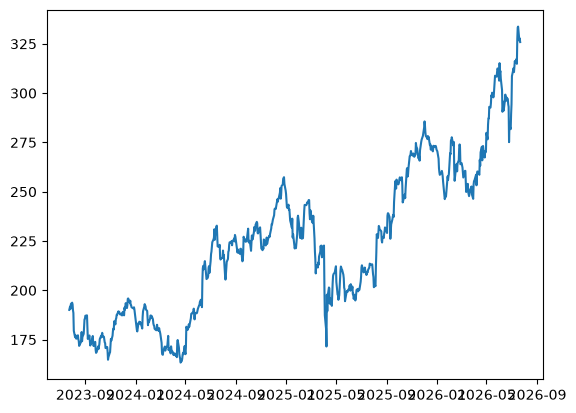

In [77]:
fig = plt.plot(aapl_df.index, aapl_df['Close'])
print(len(aapl_df))
plt.show()

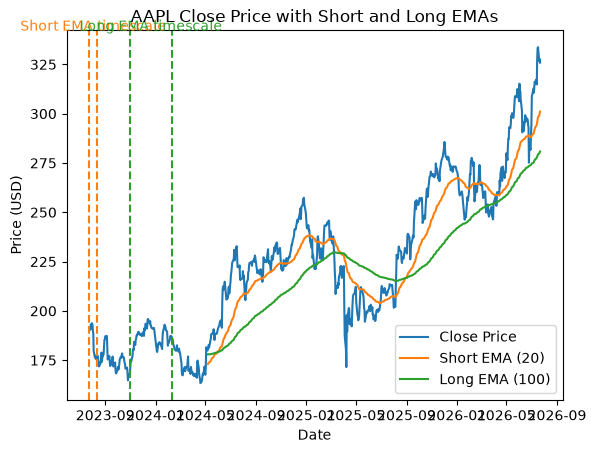

In [ ]:
short_ema = ema.get_ema_series(aapl_df, period=200, halflife=20)
long_ema = ema.get_ema_series(aapl_df, period=200, halflife=100)
l1 = plt.plot(aapl_df.index, aapl_df['Close'], color="tab:blue", label='Close Price')
l2 = plt.plot(aapl_df.index, short_ema, color="tab:orange", label='Short EMA (20)')
l3 = plt.plot(aapl_df.index, long_ema, color="tab:green", label='Long EMA (100)')
plt.axvline(x=aapl_df.index[0] + pd.DateOffset(days=0), color='tab:orange', linestyle='--')
plt.axvline(x=aapl_df.index[0] + pd.DateOffset(days=20), color='tab:orange', linestyle='--')
plt.axvline(x=aapl_df.index[0] + pd.DateOffset(days=100), color='tab:green', linestyle='--')
plt.axvline(x=aapl_df.index[0] + pd.DateOffset(days=200), color='tab:green', linestyle='--')

y_min = aapl_df['Close'].min()
y_max = aapl_df['Close'].max()
y_span = y_max - y_min
label_y_short = y_min + 0.93 * y_span
label_y_long = y_min + 0.83 * y_span

short_mid = aapl_df.index[0] + pd.DateOffset(days=10)
long_mid = aapl_df.index[0] + pd.DateOffset(days=150)
plt.text(short_mid, label_y_short, 'Short\nEMA\nwindow', color='tab:orange', ha='center', va='center', rotation=90, fontsize=9)
plt.text(long_mid, label_y_long, 'Long\nEMA\nwindow', color='tab:green', ha='center', va='center', rotation=90, fontsize=9)

plt.title("AAPL Close Price with Short and Long EMAs")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()